# Part 1: Data Preparation & Leakage-Free Pipeline
**Course:** CS-13410 Introduction to Machine Learning

**Dataset:** Heart Disease UCI (920 rows, 16 columns)

**Problem:** Predict whether a patient has heart disease (binary classification)

In [3]:
import pandas as pd
df = pd.read_csv("heart_disease_uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
df.shape

(920, 16)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [6]:
df.isna().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [7]:
(df.isna().sum() / len(df) * 100).round(1)

id           0.0
age          0.0
sex          0.0
dataset      0.0
cp           0.0
trestbps     6.4
chol         3.3
fbs          9.8
restecg      0.2
thalch       6.0
exang        6.0
oldpeak      6.7
slope       33.6
ca          66.4
thal        52.8
num          0.0
dtype: float64

In [8]:
df = df.drop(columns=["id", "ca"])
df.shape

(920, 14)

In [9]:
df["target"] = (df["num"] > 0).astype(int)
df["target"].value_counts()

target
1    509
0    411
Name: count, dtype: int64

## Problem Framing
- **Target variable:** `target` (derived from `num`: 0 = no disease, 1 = disease)
- **Task type:** Binary classification
- **Success metric:** F1-score and ROC-AUC (not accuracy alone, because missing a diseased patient is costly)
- **Columns dropped:** `id` (only a serial number) and `ca` (about 66% missing values)


In [10]:
import numpy as np
df['chol'] = df['chol'].replace(0, np.nan)
df['trestbps'] = df['trestbps'].replace(0, np.nan)

from sklearn.model_selection import train_test_split

X = df.drop(columns=["num", "target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(736, 13) (184, 13)
target
1    0.552989
0    0.447011
Name: proportion, dtype: float64
target
1    0.554348
0    0.445652
Name: proportion, dtype: float64


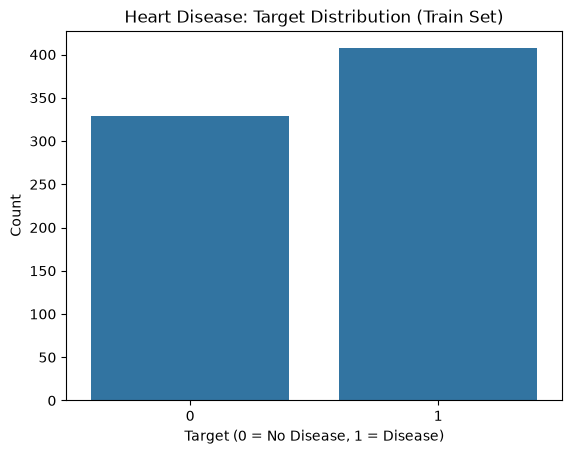

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

train = X_train.copy()
train["target"] = y_train

sns.countplot(x="target", data=train)
plt.title("Heart Disease: Target Distribution (Train Set)")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Count")
plt.show()

From this plot, we can see that The two classes are fairly balanced (about 55% disease, 45% no disease), so class imbalance is not a serious problem here. Class imbalance was checked: classes are roughly balanced (55/45), so no resampling is needed.

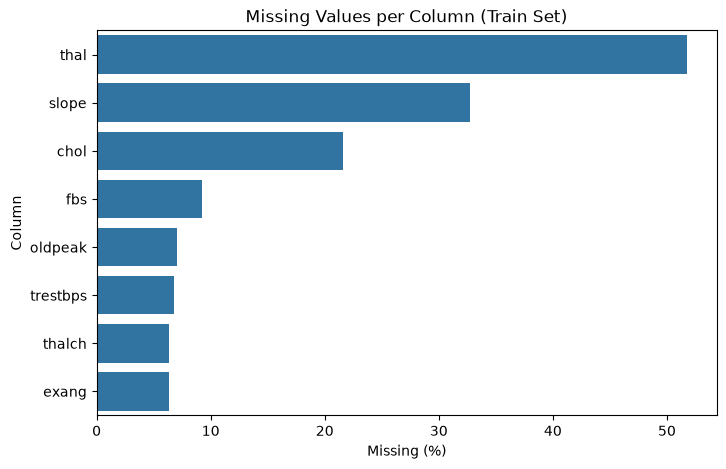

In [12]:
missing = (X_train.isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]

plt.figure(figsize=(8, 5))
sns.barplot(x=missing.values, y=missing.index)
plt.title("Missing Values per Column (Train Set)")
plt.xlabel("Missing (%)")
plt.ylabel("Column")
plt.show()

From this plot, we can see that `thal` (about 52%) and `slope` (about 33%) have the most missing values. The other columns have less than 10% missing. Missing values will be imputed inside the pipeline (median for numeric, most frequent for categorical) so that no information from the test set is used.

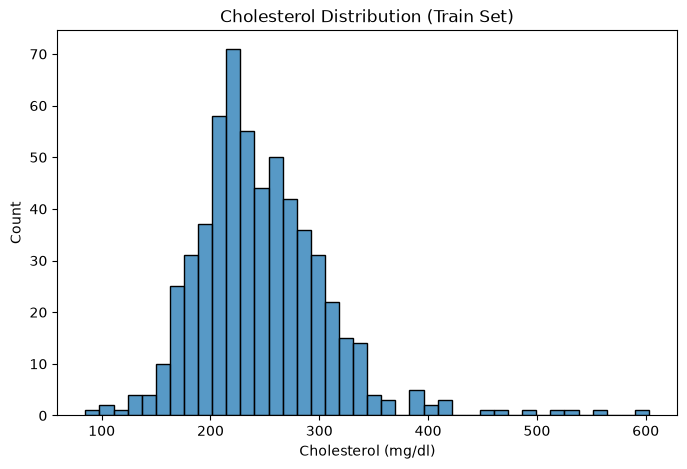

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(data=train, x="chol", bins=40)
plt.title("Cholesterol Distribution (Train Set)")
plt.xlabel("Cholesterol (mg/dl)")
plt.ylabel("Count")
plt.show()

In [14]:
import numpy as np


print((X_train[["chol", "trestbps"]].isna().mean() * 100).round(1))

chol        21.6
trestbps     6.8
dtype: float64


From this plot, we can see that The cholesterol histogram shows a large spike at 0, which is medically impossible. These zeros are hidden missing values (recorded as 0 instead of blank). They were converted to NaN so they will be imputed inside the pipeline like other missing values. The same fix was applied to `trestbps` (blood pressure).

In [15]:
train = X_train.copy()
train["target"] = y_train

"After conversion, the distribution looks normal between about 100 and 600 mg/dl."

In [16]:
num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

print("Numeric:", num_cols)
print("Categorical:", cat_cols)

Numeric: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
Categorical: ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
], sparse_threshold=0)

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print(X_train_prep.shape, X_test_prep.shape)
print("Missing after prep:", np.isnan(X_train_prep).sum())

(736, 28) (184, 28)
Missing after prep: 0


## Preprocessing Pipeline
- **Numeric columns:** missing values filled with the median, then scaled (RobustScaler).
- **Categorical columns:** missing values filled with the most frequent value, then one-hot encoded.
- The pipeline is **fit on the training set only** and then applied to the test set, so no test information leaks into training.
- Result: 13 original features became 28 after encoding, with no missing values.

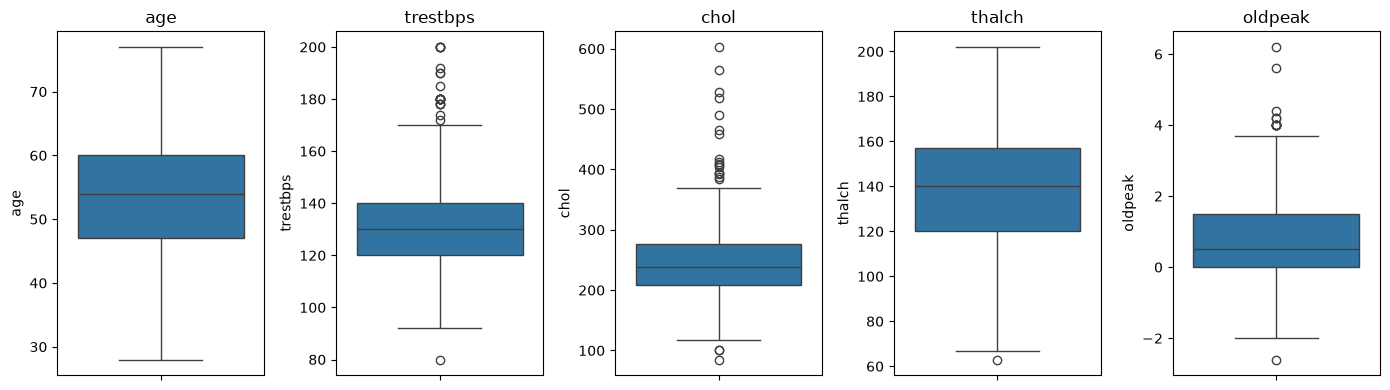

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 4))
for i, col in enumerate(num_cols):
    plt.subplot(1, 5, i + 1)
    sns.boxplot(y=X_train[col])
    plt.title(col)
plt.tight_layout()
plt.show()

## Outlier Handling
Boxplots show outliers mainly in `chol`, `trestbps` and `oldpeak`. These values are medically possible (not data errors), and the dataset is small (920 rows), so rows were not removed. Instead, RobustScaler (based on median and IQR) is used in the pipeline, which reduces the effect of outliers without discarding data. Impossible zeros in `chol` and `trestbps` were already treated as missing values.

## Feature Construction & Selection
- **Constructed feature `hr_pct`** = `thalch / (220 - age)`: the fraction of the age-predicted maximum heart rate that the patient reached during exercise. It is computed row by row, so it does not use any test information. Disease cases show a lower average (about 0.78) than healthy cases (about 0.88).
- **Dropped `dataset`** (hospital of origin): it is not a patient characteristic and would not generalize to a new patient. Disease rates differ strongly by hospital (Switzerland about 93%, Hungary about 36%), so the model could learn the hospital instead of the disease.
- **Scaler:** RobustScaler is used instead of StandardScaler because of the outliers in `chol`, `trestbps` and `oldpeak`.

In [19]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

# Feature construction: percentage of max heart rate achieved
for data in [X_train, X_test]:
    data["hr_pct"] = data["thalch"] / (220 - data["age"])

# Feature selection: drop hospital name
X_train = X_train.drop(columns=["dataset"], errors="ignore")
X_test = X_test.drop(columns=["dataset"], errors="ignore")

# Column lists
num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

# Pipelines
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
], sparse_threshold=0)

# Fit on train only, apply to test
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print("Numeric:", num_cols)
print("Categorical:", cat_cols)
print(X_train_prep.shape, X_test_prep.shape)
print("Missing after prep:", np.isnan(X_train_prep).sum(), np.isnan(X_test_prep).sum())

Numeric: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'hr_pct']
Categorical: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
(736, 25) (184, 25)
Missing after prep: 0 0
